# FastJudge V1 — entraînement sans LLM

Ce notebook entraîne un classifieur rapide pour prédire les rôles CIR/R&D :

```text
objectif, verrou, methode, parametre, variable, resultat, limite, contribution, hypothese, bruit
```

## Modèle utilisé

On n’utilise pas de LLM ici.

Le modèle est :

```text
TF-IDF mots + TF-IDF caractères
        ↓
SGDClassifier(loss="log_loss", class_weight="balanced")
```

Pourquoi ce choix :

- rapide en local ;
- pas besoin de GPU ;
- pas besoin de télécharger HuggingFace ;
- permet un entraînement par époques avec métriques à chaque époque ;
- compatible avec `predict_proba`, donc on peut avoir une confiance ;
- plus simple à analyser qu’un modèle profond.

Important : comme ton dataset est pseudo-annoté automatiquement, le modèle V1 sert à trier et prioriser les preuves, pas à remplacer la validation consultant.

In [1]:
from pathlib import Path
import json
import csv
import random
import joblib
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

print("Imports OK")

Imports OK


In [18]:
ROOT = Path(r"C:\EnnoSmart")

DATASET_PATH = ROOT / "data" / "training" / "role_classification_dataset.jsonl"

MODEL_DIR = ROOT / "models" / "fastjudge"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "fastjudge_role_classifier.pkl"
REPORT_PATH = MODEL_DIR / "fastjudge_role_classifier_report.json"
PREDICTIONS_PATH = MODEL_DIR / "fastjudge_role_classifier_predictions.csv"
CURVES_PATH = MODEL_DIR / "fastjudge_training_curves.csv"

VALID_ROLES = [
    "objectif",
    "verrou",
    "methode",
    "parametre",
    "variable",
    "resultat",
    "limite",
    "contribution",
    "hypothese",
    "bruit",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_EPOCHS = 2

print("Dataset :", DATASET_PATH)
print("Model dir:", MODEL_DIR)

Dataset : C:\EnnoSmart\data\training\role_classification_dataset.jsonl
Model dir: C:\EnnoSmart\models\fastjudge


In [19]:
def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def normalize_text(x):
    s = str(x or "")
    s = s.replace("\u00a0", " ").replace("\ufeff", " ")
    s = " ".join(s.split())
    return s.strip()


def build_input_text(row):
    text = normalize_text(row.get("text"))
    before = normalize_text(row.get("context_before"))
    after = normalize_text(row.get("context_after"))
    candidate = normalize_text(row.get("candidate_role"))
    source = normalize_text(row.get("source_type"))
    project_type = normalize_text(row.get("project_type"))

    return (
        f"{text}\n"
        f"{text}\n"
        f"CONTEXT_BEFORE: {before}\n"
        f"CONTEXT_AFTER: {after}\n"
        f"CANDIDATE_ROLE: {candidate}\n"
        f"SOURCE_TYPE: {source}\n"
        f"PROJECT_TYPE: {project_type}"
    )


def prepare_dataset(rows, min_text_len=20):
    X, y, kept = [], [], []

    for row in rows:
        role = str(row.get("role_gold") or "").strip().lower()
        text = normalize_text(row.get("text"))

        if role not in VALID_ROLES:
            continue
        if len(text) < min_text_len:
            continue

        X.append(build_input_text(row))
        y.append(role)
        kept.append(row)

    return X, y, kept


def print_distribution(title, labels):
    print("\n" + title)
    for k, v in Counter(labels).most_common():
        print(f"{k:14s} : {v}")


def safe_train_test_split(X, y, rows):
    counts = Counter(y)
    can_stratify = all(v >= 2 for v in counts.values())

    if can_stratify:
        return train_test_split(
            X, y, rows,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y,
        )

    return train_test_split(
        X, y, rows,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

In [20]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset introuvable : {DATASET_PATH}")

rows = read_jsonl(DATASET_PATH)
X, y, kept_rows = prepare_dataset(rows)

print("Lignes dataset :", len(rows))
print("Lignes utilisées :", len(X))
print_distribution("Distribution totale", y)

df_preview = pd.DataFrame(kept_rows)
display(df_preview[[
    "project_id",
    "source_type",
    "candidate_role",
    "role_gold",
    "text",
]].head(10))

Lignes dataset : 3030
Lignes utilisées : 3030

Distribution totale
bruit          : 611
resultat       : 486
methode        : 452
parametre      : 381
verrou         : 334
limite         : 264
objectif       : 253
contribution   : 185
hypothese      : 55
variable       : 9


,project_id,source_type,candidate_role,role_gold,text
0,projet_10_,raw,limite,limite,Elles se concentrent généralement sur un seul ...
1,projet_10_,raw,limite,methode,"Une fois que les critères sont définis, il est..."
2,projet_10_,raw,limite,limite,Elles se concentrent généralement sur un seul ...
3,projet_10_,raw,limite,verrou,5 Indiquer les incertitudes scientifiques et t...
4,projet_10_,raw,limite,objectif,"L’objectif est de trouver des opinions, d’iden..."
5,projet_10_,raw,limite,limite,Il existe plusieurs méthodes telles que: - Tra...
6,projet_10_,raw,limite,limite,Il est possible aussi de réaliser la réduction...
7,projet_10_,raw,limite,methode,"En détail, l'écoute des médias sociaux exploit..."
8,projet_10_,raw,limite,verrou,"Dans la littérature, bien que quelques études ..."
9,projet_10_,raw,limite,methode,Les analyseurs Web emploient des proxys pour q...


In [21]:
# ============================================================
# 3.1 Fusion des classes faibles pour FastJudge V1
# ============================================================
# Problème :
# - variable = seulement 9 exemples → trop faible pour être appris correctement
# - hypothese = 55 exemples → fragile et souvent proche de limite/incertitude
#
# Choix V1 :
# - variable  → parametre
# - hypothese → limite
#
# Les variables mesurées seront ensuite extraites par un module dédié,
# pas par le classifieur principal.

ROLE_MERGE_MAP = {
    "variable": "parametre",
    "hypothese": "limite",
}

for row in rows:
    role = str(row.get("role_gold") or "").strip().lower()
    if role in ROLE_MERGE_MAP:
        row["role_gold_original"] = role
        row["role_gold"] = ROLE_MERGE_MAP[role]
    else:
        row["role_gold_original"] = role

# Recalculer X / y / kept_rows après fusion
X, y, kept_rows = prepare_dataset(rows)

# Mettre à jour les classes utilisées par le modèle
VALID_ROLES = [
    "objectif",
    "verrou",
    "methode",
    "parametre",
    "resultat",
    "limite",
    "contribution",
    "bruit",
]

print("Fusion appliquée :")
print("variable  → parametre")
print("hypothese → limite")

print_distribution("Distribution après fusion", y)

Fusion appliquée :
variable  → parametre
hypothese → limite

Distribution après fusion
bruit          : 611
resultat       : 486
methode        : 452
parametre      : 390
verrou         : 334
limite         : 319
objectif       : 253
contribution   : 185


In [22]:
# ============================================================
# 3.1 Nettoyage dataset avant split
# Fusion classes faibles + suppression doublons
# ============================================================

import re
import hashlib
from collections import Counter

# 1. Fusion des classes faibles
ROLE_MERGE_MAP = {
    "variable": "parametre",
    "hypothese": "limite",
}

for row in rows:
    role = str(row.get("role_gold") or "").strip().lower()
    row["role_gold_original"] = role

    if role in ROLE_MERGE_MAP:
        row["role_gold"] = ROLE_MERGE_MAP[role]

# 2. Mettre à jour les rôles utilisés
VALID_ROLES = [
    "objectif",
    "verrou",
    "methode",
    "parametre",
    "resultat",
    "limite",
    "contribution",
    "bruit",
]

# 3. Déduplication exacte / quasi exacte
def normalize_for_dedup(text):
    text = str(text or "").lower()
    text = text.replace("’", "'")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s%°.,;:']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def text_hash(text):
    return hashlib.md5(normalize_for_dedup(text).encode("utf-8", errors="ignore")).hexdigest()

dedup_rows = []
seen = set()

# On garde la meilleure ligne si doublon :
# priorité à raw_plus_cir, puis raw, puis quality_score élevé
def row_quality(row):
    score = 0
    if row.get("project_type") == "raw_plus_cir":
        score += 2
    if row.get("source_type") == "raw":
        score += 1
    try:
        score += float(row.get("quality_score") or 0)
    except Exception:
        pass
    return score

rows_sorted = sorted(rows, key=row_quality, reverse=True)

for row in rows_sorted:
    role = str(row.get("role_gold") or "").strip().lower()
    text = row.get("text", "")

    if role not in VALID_ROLES:
        continue

    h = text_hash(text)

    if h in seen:
        continue

    seen.add(h)
    dedup_rows.append(row)

rows = dedup_rows

# 4. Recalculer X / y / kept_rows après fusion + déduplication
X, y, kept_rows = prepare_dataset(rows)

print("Après fusion + déduplication")
print("Lignes utilisées :", len(X))
print_distribution("Distribution après nettoyage", y)

Après fusion + déduplication
Lignes utilisées : 3025

Distribution après nettoyage
bruit          : 609
resultat       : 486
methode        : 451
parametre      : 390
verrou         : 333
limite         : 319
objectif       : 252
contribution   : 185


In [23]:
# ============================================================
# 4. Split train / validation par projet
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
import numpy as np

groups = np.array([row.get("project_id", "unknown") for row in kept_rows])
y_array = np.array(y)
indices = np.arange(len(X))

use_group_split = True

if use_group_split:
    try:
        splitter = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        train_idx, val_idx = next(splitter.split(indices, y_array, groups))

        print("Split utilisé : StratifiedGroupKFold par projet")

    except Exception as e:
        print("StratifiedGroupKFold impossible, fallback GroupShuffleSplit")
        print("Erreur :", e)

        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE
        )

        train_idx, val_idx = next(splitter.split(indices, y_array, groups))

        print("Split utilisé : GroupShuffleSplit par projet")

    X_train = [X[i] for i in train_idx]
    X_val = [X[i] for i in val_idx]

    y_train = [y[i] for i in train_idx]
    y_val = [y[i] for i in val_idx]

    rows_train = [kept_rows[i] for i in train_idx]
    rows_val = [kept_rows[i] for i in val_idx]

else:
    X_train, X_val, y_train, y_val, rows_train, rows_val = safe_train_test_split(X, y, kept_rows)

print("Train :", len(X_train))
print("Val   :", len(X_val))

print_distribution("Distribution train", y_train)
print_distribution("Distribution val", y_val)

print("Projets train :", len(set(r.get("project_id") for r in rows_train)))
print("Projets val   :", len(set(r.get("project_id") for r in rows_val)))

Split utilisé : StratifiedGroupKFold par projet
Train : 2344
Val   : 681

Distribution train
bruit          : 493
resultat       : 368
methode        : 359
limite         : 273
verrou         : 270
parametre      : 239
objectif       : 198
contribution   : 144

Distribution val
parametre      : 151
resultat       : 118
bruit          : 116
methode        : 92
verrou         : 63
objectif       : 54
limite         : 46
contribution   : 41
Projets train : 21
Projets val   : 6


In [24]:
# ============================================================
# 4.1 Data augmentation légère sur TRAIN seulement
# ============================================================
# Objectif :
# - éviter que le modèle dépende trop de candidate_role
# - créer des variantes avec ou sans contexte
# - renforcer un peu les classes moins nombreuses

AUGMENT_TRAIN = True

def augment_training_rows(X_train, y_train, rows_train):
    aug_X = list(X_train)
    aug_y = list(y_train)
    aug_rows = list(rows_train)

    class_counts = Counter(y_train)
    max_target = int(np.median(list(class_counts.values())))

    for x, label, row in zip(X_train, y_train, rows_train):
        text = normalize_text(row.get("text"))
        before = normalize_text(row.get("context_before"))
        after = normalize_text(row.get("context_after"))

        # Variante 1 : texte seul
        if label in {"objectif", "verrou", "limite", "contribution"}:
            aug_X.append(text)
            aug_y.append(label)
            aug_rows.append(row)

        # Variante 2 : texte + contexte sans candidate_role
        if label in {"methode", "resultat", "parametre"}:
            aug_X.append(
                f"{text}\nCONTEXT_BEFORE: {before}\nCONTEXT_AFTER: {after}"
            )
            aug_y.append(label)
            aug_rows.append(row)

        # Variante 3 : sur-échantillonnage doux pour classes faibles
        if class_counts[label] < max_target:
            aug_X.append(
                f"{text}\n{text}\nCONTEXT_BEFORE: {before}\nCONTEXT_AFTER: {after}"
            )
            aug_y.append(label)
            aug_rows.append(row)

    return aug_X, aug_y, aug_rows

if AUGMENT_TRAIN:
    X_train, y_train, rows_train = augment_training_rows(X_train, y_train, rows_train)

print("Après augmentation TRAIN")
print("Train :", len(X_train))
print("Val   :", len(X_val))
print_distribution("Distribution train augmentée", y_train)
print_distribution("Distribution val non augmentée", y_val)

Après augmentation TRAIN
Train : 5046
Val   : 681

Distribution train augmentée
verrou         : 810
resultat       : 736
methode        : 718
parametre      : 717
objectif       : 594
limite         : 546
bruit          : 493
contribution   : 432

Distribution val non augmentée
parametre      : 151
resultat       : 118
bruit          : 116
methode        : 92
verrou         : 63
objectif       : 54
limite         : 46
contribution   : 41


In [25]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
    lowercase=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 6),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode",
    lowercase=True,
)

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf),
])

print("Fit vectorizer...")
X_train_vec = features.fit_transform(X_train)
X_val_vec = features.transform(X_val)

print("X_train_vec:", X_train_vec.shape)
print("X_val_vec  :", X_val_vec.shape)

Fit vectorizer...
X_train_vec: (5046, 242520)
X_val_vec  : (681, 242520)


In [42]:
# ============================================================
# 6. Modèle FastJudge V1
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.array(VALID_ROLES)

# Calcul manuel des poids de classes pour compenser le déséquilibre
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.array(y_train)
)

class_weights = {
    cls: float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Poids des classes :")
for cls, weight in class_weights.items():
    print(f"{cls:14s} : {weight:.3f}")

# SGDClassifier avec log_loss = régression logistique entraînée par descente de gradient.
# On passe class_weight sous forme de dict, car partial_fit n'accepte pas class_weight='balanced'.
clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=5e-5,
    max_iter=1,
    tol=None,
    learning_rate="optimal",
    class_weight=class_weights,
    random_state=RANDOM_STATE,
)

print("Modèle :", clf)

Poids des classes :
objectif       : 1.062
verrou         : 0.779
methode        : 0.878
parametre      : 0.880
resultat       : 0.857
limite         : 1.155
contribution   : 1.460
bruit          : 1.279
Modèle : SGDClassifier(alpha=5e-05,
              class_weight={np.str_('bruit'): 1.2794117647058822,
                            np.str_('contribution'): 1.4600694444444444,
                            np.str_('limite'): 1.1552197802197801,
                            np.str_('methode'): 0.8784818941504178,
                            np.str_('objectif'): 1.0618686868686869,
                            np.str_('parametre'): 0.8797071129707112,
                            np.str_('resultat'): 0.8569972826086957,
                            np.str_('verrou'): 0.7787037037037037},
              loss='log_loss', max_iter=1, random_state=42, tol=None)


In [43]:
history = []

X_train_arr = X_train_vec
y_train_arr = np.array(y_train)

for epoch in range(1, N_EPOCHS + 1):
    X_epoch, y_epoch = shuffle(X_train_arr, y_train_arr, random_state=RANDOM_STATE + epoch)

    if epoch == 1:
        clf.partial_fit(X_epoch, y_epoch, classes=classes)
    else:
        clf.partial_fit(X_epoch, y_epoch)

    train_pred = clf.predict(X_train_vec)
    val_pred = clf.predict(X_val_vec)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_macro_f1 = f1_score(y_train, train_pred, average="macro", zero_division=0)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)

    train_weighted_f1 = f1_score(y_train, train_pred, average="weighted", zero_division=0)
    val_weighted_f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)

    history.append({
        "epoch": epoch,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_weighted_f1": val_weighted_f1,
    })

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
        f"train_macro_f1={train_macro_f1:.4f} | val_macro_f1={val_macro_f1:.4f} | "
        f"val_weighted_f1={val_weighted_f1:.4f}"
    )

history_df = pd.DataFrame(history)
history_df.to_csv(CURVES_PATH, index=False, encoding="utf-8-sig")
display(history_df)
print("Courbes sauvegardées :", CURVES_PATH)

Epoch 01/2 | train_acc=0.9727 | val_acc=0.7460 | train_macro_f1=0.9734 | val_macro_f1=0.7583 | val_weighted_f1=0.7214
Epoch 02/2 | train_acc=0.9907 | val_acc=0.8179 | train_macro_f1=0.9911 | val_macro_f1=0.8149 | val_weighted_f1=0.8137


,epoch,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,1,0.972652,0.745962,0.973397,0.758278,0.972623,0.721357
1,2,0.990686,0.817915,0.991118,0.814930,0.990683,0.813652


Courbes sauvegardées : C:\EnnoSmart\models\fastjudge\fastjudge_training_curves.csv


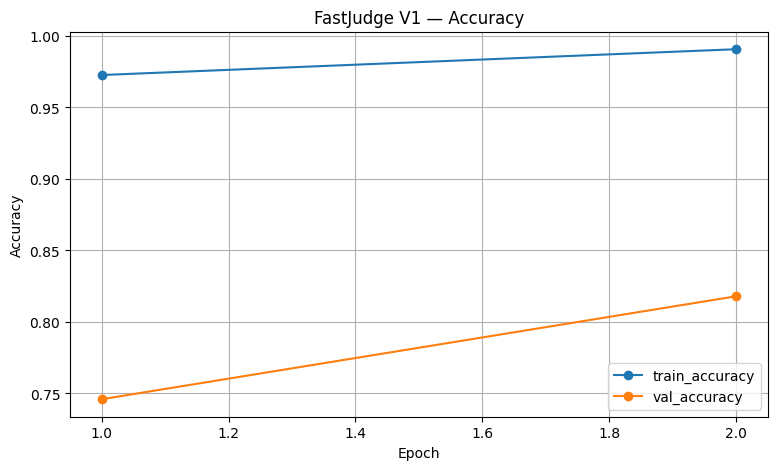

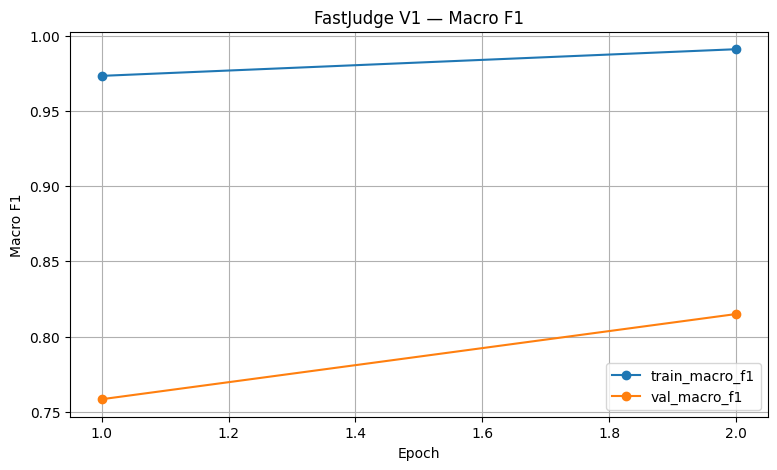

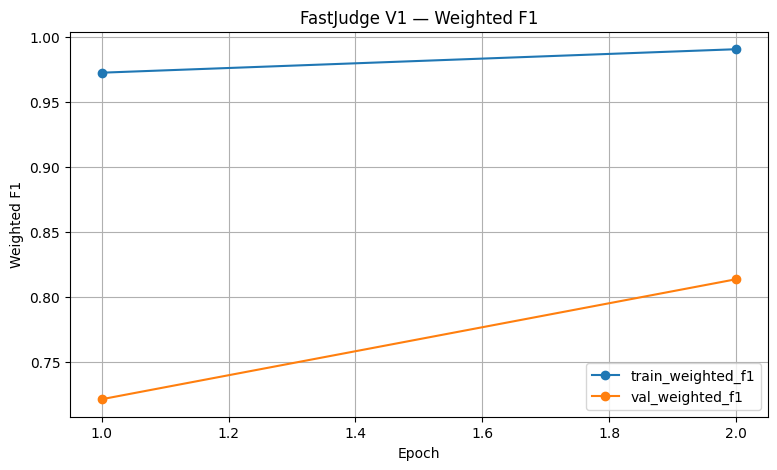

In [44]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train_accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FastJudge V1 — Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("FastJudge V1 — Macro F1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_weighted_f1"], marker="o", label="train_weighted_f1")
plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o", label="val_weighted_f1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("FastJudge V1 — Weighted F1")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
y_val_pred = clf.predict(X_val_vec)

print("Accuracy validation :", accuracy_score(y_val, y_val_pred))
print("Macro F1 validation :", f1_score(y_val, y_val_pred, average="macro", zero_division=0))
print("Weighted F1 validation :", f1_score(y_val, y_val_pred, average="weighted", zero_division=0))

report_text = classification_report(
    y_val,
    y_val_pred,
    labels=VALID_ROLES,
    zero_division=0,
)

report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=VALID_ROLES,
    output_dict=True,
    zero_division=0,
)

print(report_text)

Accuracy validation : 0.8179148311306902
Macro F1 validation : 0.8149301825896546
Weighted F1 validation : 0.8136519955810402
              precision    recall  f1-score   support

    objectif       0.84      0.94      0.89        54
      verrou       0.67      0.87      0.76        63
     methode       0.85      0.68      0.76        92
   parametre       0.93      0.62      0.75       151
    resultat       0.81      0.91      0.86       118
      limite       0.90      0.96      0.93        46
contribution       0.65      0.73      0.69        41
       bruit       0.83      0.97      0.90       116

    accuracy                           0.82       681
   macro avg       0.81      0.84      0.81       681
weighted avg       0.83      0.82      0.81       681



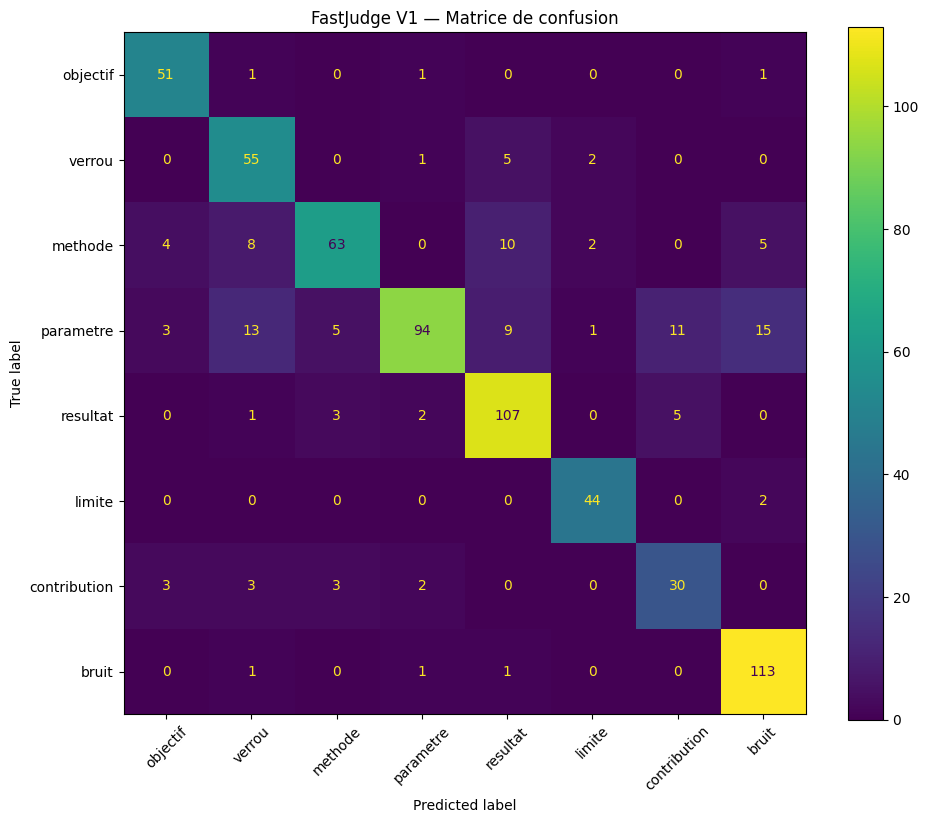

In [46]:
cm = confusion_matrix(y_val, y_val_pred, labels=VALID_ROLES)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_ROLES)
fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("FastJudge V1 — Matrice de confusion")
plt.show()

In [47]:
proba = clf.predict_proba(X_val_vec)
conf = proba.max(axis=1)

errors = []
for row, true, pred, c in zip(rows_val, y_val, y_val_pred, conf):
    if true != pred:
        errors.append({
            "project_id": row.get("project_id"),
            "source_type": row.get("source_type"),
            "source_doc": row.get("source_doc"),
            "candidate_role": row.get("candidate_role"),
            "role_gold": true,
            "role_pred": pred,
            "pred_confidence": round(float(c), 4),
            "text": row.get("text"),
            "context_before": row.get("context_before"),
            "context_after": row.get("context_after"),
        })

errors_df = pd.DataFrame(errors).sort_values("pred_confidence", ascending=False)
print("Nombre erreurs :", len(errors_df))
display(errors_df.head(50))

Nombre erreurs : 124


,project_id,source_type,source_doc,candidate_role,role_gold,role_pred,pred_confidence,text,context_before,context_after
90,projet_3_,raw,Pelvipharm_projets 2024_2025-06-02.docx,unknown,parametre,bruit,0.9191,Cela rendait difficile la déterminer de la dos...,"Plus précisément, sans ces données, nous ne sa...","En outre, peu d’études précliniques ont évalué..."
87,projet_13_,raw,Première version DT Water Quality.msg,unknown,parametre,bruit,0.9095,Harvey9 ont utilisé les concentrations de chlo...,D.,Ils ont étudié la faisabilité de détecter les ...
86,projet_13_,raw,Première version DT Water Quality.msg,unknown,methode,bruit,0.9076,Cette procédure était nécessaire dans le cadre...,L'auteur a utilisé une procédure semi-automati...,"Ensuite, une étude de la dynamique spatio-temp..."
36,projet_3_,raw,PIIS016561470600174X.pdf,verrou,bruit,verrou,0.8931,"Moreover, the use of muscarinic acetylcholine ...",Recent data indicate that continent OAB [10].,Bladder contractions during the storage tantly...
122,projet_13_,cir_final,SCALIAN-DS_DT-2024_Wter-Quality_VF_AD.docx,unknown,parametre,bruit,0.8645,Leur méthode repose sur un réseau appelé Water...,Syariz et al. ont introduit une approche s’app...,Le modèle s’appuie sur une image 3D composée d...
120,projet_13_,cir_final,SCALIAN-DS_DT-2024_Wter-Quality_VF_AD.docx,unknown,methode,bruit,0.8616,Cette méthode repose sur l'analyse des caracté...,L'identification taxonomique et la quantificat...,"Cependant, cette approche nécessite un équipem..."
102,projet_13_,cir_final,SCALIAN-DS_DT-2024_Wter-Quality_VF_AD.docx,objectif,methode,objectif,0.8460,L’objectif initial est de proposer un modèle p...,Ces derniers s’inscrivent dans le cadre du pro...,Cette tâche est très proche des travaux réalis...
85,projet_13_,raw,Première version DT Water Quality.msg,unknown,parametre,bruit,0.8359,S | Les différentes approches pour la détectio...,Cao et al.,Cette approche est basée sur la corrélation fr...
121,projet_13_,cir_final,SCALIAN-DS_DT-2024_Wter-Quality_VF_AD.docx,unknown,parametre,bruit,0.8336,De nombreuses méthodes de détection des efflor...,"Selon notre revue de la littérature, cinq prin...",Cette approche repose sur la corrélation fréqu...
123,projet_32_,cir_final,CIR2025_ENERGEO_NATRAN_VF.docx,bruit,methode,bruit,0.8307,"Une analyse approfondie de l’état de l’art, dé...",,"L’hydrogène, en tant que molécule diatomique l..."


In [48]:
pred_rows = []

for row, true, pred, p in zip(rows_val, y_val, y_val_pred, proba):
    pred_rows.append({
        "project_id": row.get("project_id"),
        "source_type": row.get("source_type"),
        "source_doc": row.get("source_doc"),
        "candidate_role": row.get("candidate_role"),
        "role_gold": true,
        "role_pred": pred,
        "pred_confidence": round(float(np.max(p)), 4),
        "is_correct": true == pred,
        "text": row.get("text"),
        "context_before": row.get("context_before"),
        "context_after": row.get("context_after"),
    })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")

print("Prédictions sauvegardées :", PREDICTIONS_PATH)
display(pred_df.head(10))

Prédictions sauvegardées : C:\EnnoSmart\models\fastjudge\fastjudge_role_classifier_predictions.csv


,project_id,source_type,source_doc,candidate_role,role_gold,role_pred,pred_confidence,is_correct,text,context_before,context_after
0,projet_13_,raw,Première version DT Water Quality.msg,limite,limite,limite,0.6235,True,"D'après les études que nous avons examinées, l...","Beck et al.15, les auteurs fournissent une rev...","Néanmoins, la phycocyanine est plus difficile ..."
1,projet_3_,raw,Pelvipharm_fiche projet 2024 PCOS.docx,limite,methode,resultat,0.6317,False,Les résultats sur les deux autres critères ne ...,Les premières observations que nous avons réal...,D’autres analyses sont en cours pour compléter...
2,projet_3_,raw,Dossier agrément_Vet4Science_2025-03-18.docx,limite,methode,resultat,0.6317,False,Les résultats sur les deux autres critères ne ...,"Figure : Résultats obtenus (violet : rat GK, p...",D’autres analyses sont en cours pour compléter...
3,projet_3_,raw,Dossier agrément_Vet4Science_2025-03-18.docx,limite,limite,limite,0.6581,True,"Ainsi, nos premiers résultats semblent confirm...",Si cette dernière observation se confirme avec...,"De plus, ces rates ont une intolérance au gluc..."
4,projet_3_,raw,Pelvipharm_projets 2024_2025-06-12 (client).docx,limite,methode,resultat,0.6400,False,Les résultats sur les deux autres critères ne ...,Les premières observations que nous avons réal...,D’autres analyses sont en cours pour compléter...
5,projet_9_,raw,TCP R&I_CIR_2024_Ed1.1.docx,limite,limite,limite,0.7402,True,"L’objectif de TCP R&I, au-delà de la nécessité...",Cette R&D&I intègre l’ensemble des phases proj...,Figure : Equipements TCP R&I L’organigramme de...
6,projet_9_,raw,TCP R&I_CIR_2024_Ed1.1.docx,limite,limite,limite,0.7032,True,Les résultats de l’ensemble des travaux et ess...,"Ainsi, à l’issue des évaluations réalisées sur...",Figure : Plan d’architecture de notre système ...
7,projet_9_,raw,TCP R&I_CIR__2024_Ed1.0.docx,limite,limite,limite,0.7157,True,Les résultats de l’ensemble des travaux et ess...,"Ainsi, à l’issue des évaluations réalisées sur...",Figure : Plan d’architecture de notre système ...
8,projet_13_,raw,Première version DT Water Quality.msg,methode,methode,methode,0.8355,True,Cette solution est bien sûr coûteuse et nécess...,Cette méthode est basée sur les caractéristiqu...,La télédétection est une alternative à ces mét...
9,projet_13_,raw,Première version DT Water Quality.msg,methode,methode,methode,0.6208,True,"Avec leurs modèles, la corrélation entre les i...",La classification ou les régressions sont appl...,Ceci montre une grande différence de performan...


In [32]:
pipeline = Pipeline([
    ("features", features),
    ("clf", clf),
])

bundle = {
    "model": pipeline,
    "labels": list(clf.classes_),
    "valid_roles": VALID_ROLES,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model_version": "fastjudge_v1_tfidf_sgd_logloss",
    "model_description": "TF-IDF word+char + SGDClassifier(log_loss, class_weight=balanced)",
    "dataset_path": str(DATASET_PATH),
    "n_train": len(X_train),
    "n_val": len(X_val),
    "history": history,
    "warning": (
        "Dataset issu de pseudo-annotations automatiques. "
        "FastJudge V1 doit être utilisé pour tri/priorisation, pas comme vérité absolue."
    ),
}

joblib.dump(bundle, MODEL_PATH)

summary = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model_version": bundle["model_version"],
    "model_description": bundle["model_description"],
    "dataset_path": str(DATASET_PATH),
    "model_path": str(MODEL_PATH),
    "predictions_path": str(PREDICTIONS_PATH),
    "curves_path": str(CURVES_PATH),
    "n_total": len(rows),
    "n_used": len(X),
    "n_train": len(X_train),
    "n_val": len(X_val),
    "distribution_total": dict(Counter(y)),
    "distribution_train": dict(Counter(y_train)),
    "distribution_val": dict(Counter(y_val)),
    "final_accuracy": round(float(accuracy_score(y_val, y_val_pred)), 4),
    "final_macro_f1": round(float(f1_score(y_val, y_val_pred, average="macro", zero_division=0)), 4),
    "final_weighted_f1": round(float(f1_score(y_val, y_val_pred, average="weighted", zero_division=0)), 4),
    "classification_report": report_dict,
    "classification_report_text": report_text,
    "confusion_matrix_labels": VALID_ROLES,
    "confusion_matrix": cm.tolist(),
    "history": history,
    "warning": bundle["warning"],
}

REPORT_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("Modèle sauvegardé :", MODEL_PATH)
print("Rapport sauvegardé:", REPORT_PATH)

Modèle sauvegardé : C:\EnnoSmart\models\fastjudge\fastjudge_role_classifier.pkl
Rapport sauvegardé: C:\EnnoSmart\models\fastjudge\fastjudge_role_classifier_report.json


In [ ]:
# ============================================================
# 14. Test rapide du modèle sauvegardé avec candidate_role
# ============================================================

loaded = joblib.load(MODEL_PATH)
loaded_model = loaded["model"]

test_examples = [
    {
        "text": "Aucune différence significative n'a été observée entre les modalités.",
        "candidate_role": "resultat",
    },
    {
        "text": "Un comptage des fruits griffés est nécessaire pour évaluer le pourcentage de fruits touchés.",
        "candidate_role": "methode",
    },
    {
        "text": "Ces essais devront être poursuivis sur les prochaines années pour confirmer les tendances.",
        "candidate_role": "limite",
    },
    {
        "text": "L’objectif est d’évaluer l’efficacité du protocole dans différentes conditions.",
        "candidate_role": "objectif",
    },
    {
        "text": "Le principal verrou réside dans la difficulté à maîtriser le comportement du système.",
        "candidate_role": "verrou",
    },
    {
        "text": "Sommaire du document.",
        "candidate_role": "bruit",
    },
]

for ex in test_examples:
    x = build_input_text({
        "text": ex["text"],
        "context_before": "",
        "context_after": "",
        "candidate_role": ex["candidate_role"],
        "source_type": "raw",
        "project_type": "raw_plus_cir",
    })

    pred = loaded_model.predict([x])[0]
    prob = loaded_model.predict_proba([x])[0]
    conf = float(prob.max())

    print(
        f"{pred:12s} | conf={conf:.3f} | "
        f"candidate={ex['candidate_role']:10s} | {ex['text']}"
    )

bruit        | conf=0.647 | Aucune différence significative n'a été observée entre les modalités.
bruit        | conf=0.813 | Un comptage des fruits griffés est nécessaire pour évaluer le pourcentage de fruits touchés.
bruit        | conf=0.903 | Ces essais devront être poursuivis sur les prochaines années pour confirmer les tendances.
objectif     | conf=0.528 | L’objectif est d’évaluer l’efficacité du protocole dans différentes conditions.
verrou       | conf=0.929 | Le principal verrou réside dans la difficulté à maîtriser le comportement du système.
bruit        | conf=0.930 | Sommaire du document.
